# Heart Disease Prediction - PCA Analysis

## Principal Component Analysis for Dimensionality Reduction

### Objectives
- Apply PCA to reduce feature dimensionality while retaining essential information
- Determine optimal number of principal components using explained variance
- Visualize PCA results and cumulative variance analysis
- Prepare transformed dataset for machine learning models

### Key Benefits of PCA
- **Dimensionality Reduction**: Reduces computational complexity
- **Noise Reduction**: Filters out less important variations
- **Visualization**: Enables 2D/3D plotting of high-dimensional data
- **Multicollinearity**: Addresses correlation between features

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("🔬 Ready for PCA analysis")

✅ Libraries imported successfully!
🔬 Ready for PCA analysis


## 1. Load Processed Data

Load the preprocessed dataset from the previous notebook:

In [2]:
# Load processed dataset
try:
    df = pd.read_csv('../data/heart_disease_processed.csv')
    print(f"✅ Dataset loaded successfully: {df.shape}")
    
    # Display basic info
    print(f"📊 Features: {df.shape[1]-1}")
    print(f"📈 Instances: {df.shape[0]}")
    print(f"🎯 Target distribution:")
    print(df['target'].value_counts().sort_index())
    
except FileNotFoundError:
    print("❌ Processed dataset not found. Please run 01_data_preprocessing.ipynb first.")
    
# Prepare features and target
if 'df' in locals():
    X = df.drop('target', axis=1)
    y = df['target']
    
    print(f"\n📋 Features for PCA: {list(X.columns)}")
    print(f"🔢 Number of features: {X.shape[1]}")
    
    # Display first few rows
    print("\n👀 First 5 rows:")
    display(df.head())

✅ Dataset loaded successfully: (920, 14)
📊 Features: 13
📈 Instances: 920
🎯 Target distribution:
target
0    411
1    509
Name: count, dtype: int64

📋 Features for PCA: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
🔢 Number of features: 13

👀 First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1.007386,1.0,1.0,0.717803,-0.212194,1.0,2.0,0.489727,0.0,1.368109,3.0,0.0,6.0,0
1,1.432034,1.0,4.0,1.554856,0.807376,0.0,2.0,-1.181478,1.0,0.611589,2.0,3.0,3.0,1
2,1.432034,1.0,4.0,-0.677285,-0.289143,0.0,2.0,-0.345875,1.0,1.651804,2.0,2.0,7.0,1
3,-1.752828,1.0,3.0,-0.119250,0.114838,0.0,0.0,1.961979,0.0,2.502889,3.0,0.0,3.0,0
4,-1.328180,0.0,2.0,-0.119250,-0.770073,0.0,2.0,1.365120,0.0,0.517024,1.0,0.0,3.0,0


## 2. Apply PCA with Full Components

First, apply PCA with all components to analyze the explained variance:

In [3]:
# Apply PCA with all components
if 'X' in locals():
    # Ensure data is scaled (it should be from preprocessing)
    print("🔬 Applying PCA Analysis...")
    
    # Apply PCA with all components
    pca_full = PCA()
    X_pca_full = pca_full.fit_transform(X)
    
    # Get explained variance
    explained_variance = pca_full.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    print(f"\n📊 PCA Results:")
    print(f"Original features: {X.shape[1]}")
    print(f"Principal components: {len(explained_variance)}")
    print(f"Total variance explained: {cumulative_variance[-1]:.4f}")
    
    # Show explained variance for each component
    print(f"\n🔍 Explained Variance by Component:")
    print("=" * 50)
    for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
        print(f"PC{i+1:2d}: {var:.4f} ({var*100:.2f}%) | Cumulative: {cum_var:.4f} ({cum_var*100:.2f}%)")
    
    # Find components needed for different variance thresholds
    thresholds = [0.80, 0.90, 0.95, 0.99]
    print(f"\n🎯 Components needed for variance thresholds:")
    for threshold in thresholds:
        n_components = np.argmax(cumulative_variance >= threshold) + 1
        print(f"{threshold:.0%} variance: {n_components} components")
        
else:
    print("❌ Data not available for PCA analysis")

🔬 Applying PCA Analysis...

📊 PCA Results:
Original features: 13
Principal components: 13
Total variance explained: 1.0000

🔍 Explained Variance by Component:
PC 1: 0.2982 (29.82%) | Cumulative: 0.2982 (29.82%)
PC 2: 0.1583 (15.83%) | Cumulative: 0.4565 (45.65%)
PC 3: 0.1037 (10.37%) | Cumulative: 0.5602 (56.02%)
PC 4: 0.0919 (9.19%) | Cumulative: 0.6521 (65.21%)
PC 5: 0.0824 (8.24%) | Cumulative: 0.7344 (73.44%)
PC 6: 0.0747 (7.47%) | Cumulative: 0.8091 (80.91%)
PC 7: 0.0570 (5.70%) | Cumulative: 0.8662 (86.62%)
PC 8: 0.0453 (4.53%) | Cumulative: 0.9115 (91.15%)
PC 9: 0.0293 (2.93%) | Cumulative: 0.9407 (94.07%)
PC10: 0.0199 (1.99%) | Cumulative: 0.9607 (96.07%)
PC11: 0.0147 (1.47%) | Cumulative: 0.9754 (97.54%)
PC12: 0.0140 (1.40%) | Cumulative: 0.9894 (98.94%)
PC13: 0.0106 (1.06%) | Cumulative: 1.0000 (100.00%)

🎯 Components needed for variance thresholds:
80% variance: 6 components
90% variance: 8 components
95% variance: 10 components
99% variance: 13 components


## 3. Visualize PCA Results

Create comprehensive visualizations of the PCA analysis:

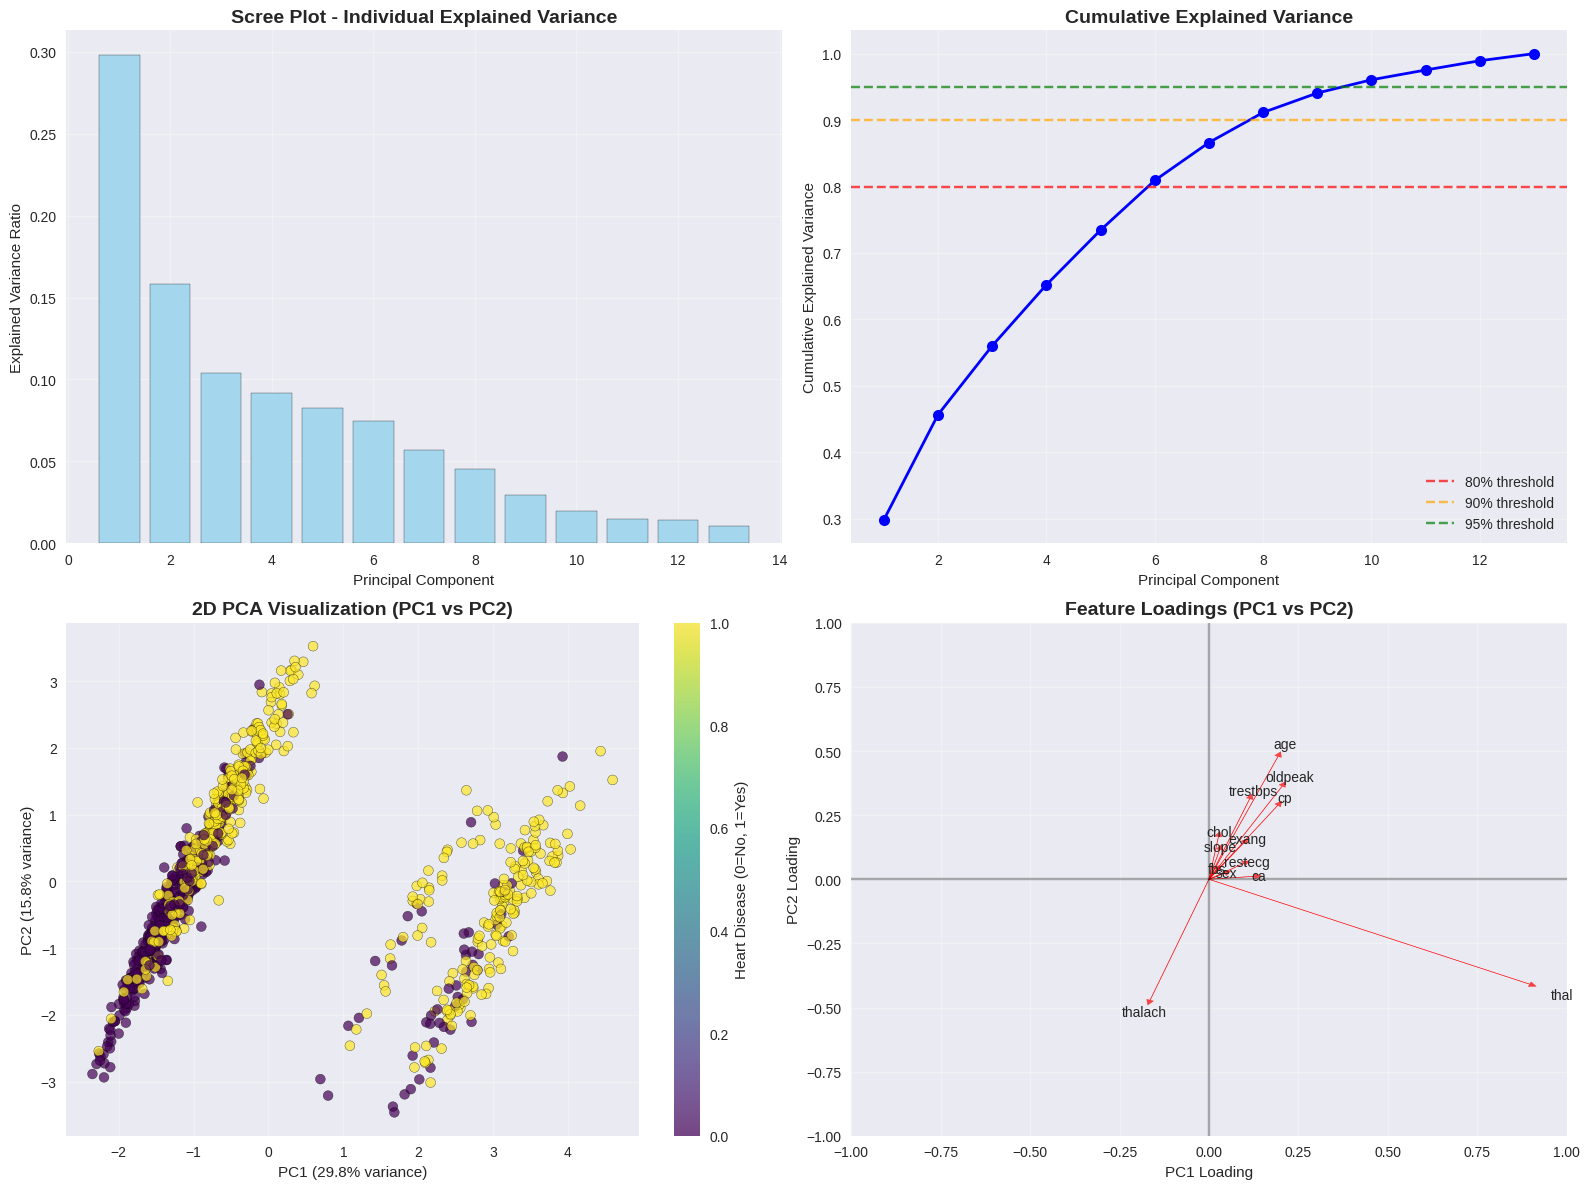

In [4]:
# Visualize PCA results
if 'explained_variance' in locals():
    # Create subplots for PCA visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Scree plot - Individual explained variance
    axes[0, 0].bar(range(1, len(explained_variance) + 1), explained_variance, 
                   alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Scree Plot - Individual Explained Variance', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Principal Component')
    axes[0, 0].set_ylabel('Explained Variance Ratio')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Cumulative explained variance
    axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
                    'bo-', linewidth=2, markersize=8)
    axes[0, 1].axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
    axes[0, 1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
    axes[0, 1].axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
    axes[0, 1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Principal Component')
    axes[0, 1].set_ylabel('Cumulative Explained Variance')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 2D PCA visualization (first 2 components)
    scatter = axes[1, 0].scatter(X_pca_full[:, 0], X_pca_full[:, 1], 
                                c=y, cmap='viridis', alpha=0.7, s=50, edgecolors='black')
    axes[1, 0].set_title('2D PCA Visualization (PC1 vs PC2)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
    axes[1, 0].set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[1, 0])
    cbar.set_label('Heart Disease (0=No, 1=Yes)')
    
    # 4. Feature loadings for first 2 components
    feature_names = X.columns
    loadings = pca_full.components_[:2].T  # First 2 components
    
    # Create loading plot
    for i, (feature, loading) in enumerate(zip(feature_names, loadings)):
        axes[1, 1].arrow(0, 0, loading[0], loading[1], 
                        head_width=0.02, head_length=0.02, fc='red', ec='red', alpha=0.7)
        axes[1, 1].text(loading[0]*1.1, loading[1]*1.1, feature, 
                       fontsize=10, ha='center', va='center')
    
    axes[1, 1].set_xlim(-1, 1)
    axes[1, 1].set_ylim(-1, 1)
    axes[1, 1].set_title('Feature Loadings (PC1 vs PC2)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('PC1 Loading')
    axes[1, 1].set_ylabel('PC2 Loading')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[1, 1].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ PCA results not available for visualization")

## 4. Optimal Number of Components

Determine the optimal number of components based on explained variance:

In [5]:
# Determine optimal number of components
if 'cumulative_variance' in locals():
    # Different criteria for selecting components
    print("🎯 Component Selection Criteria:")
    print("=" * 50)
    
    # 1. Kaiser criterion (eigenvalue > 1)
    eigenvalues = pca_full.explained_variance_
    kaiser_components = np.sum(eigenvalues > 1)
    print(f"Kaiser Criterion (eigenvalue > 1): {kaiser_components} components")
    
    # 2. Percentage of variance explained
    var_90 = np.argmax(cumulative_variance >= 0.90) + 1
    var_95 = np.argmax(cumulative_variance >= 0.95) + 1
    print(f"90% variance explained: {var_90} components")
    print(f"95% variance explained: {var_95} components")
    
    # 3. Elbow method - find the "elbow" in scree plot
    # Calculate second derivative to find elbow
    first_diff = np.diff(explained_variance)
    second_diff = np.diff(first_diff)
    elbow_point = np.argmax(second_diff) + 2  # +2 due to double differencing
    print(f"Elbow method: {elbow_point} components")
    
    # Recommended selection based on 90% variance
    optimal_components = var_90
    print(f"\n✅ Recommended: {optimal_components} components (captures {cumulative_variance[optimal_components-1]:.1%} variance)")
    
    # Apply PCA with optimal number of components
    pca_optimal = PCA(n_components=optimal_components)
    X_pca_optimal = pca_optimal.fit_transform(X)
    
    print(f"\n📊 Optimal PCA Results:")
    print(f"Original dimensions: {X.shape}")
    print(f"Reduced dimensions: {X_pca_optimal.shape}")
    print(f"Dimensionality reduction: {(1 - optimal_components/X.shape[1]):.1%}")
    print(f"Variance retained: {cumulative_variance[optimal_components-1]:.1%}")
    
else:
    print("❌ Cumulative variance not available for component selection")

🎯 Component Selection Criteria:
Kaiser Criterion (eigenvalue > 1): 3 components
90% variance explained: 8 components
95% variance explained: 10 components
Elbow method: 2 components

✅ Recommended: 8 components (captures 91.1% variance)

📊 Optimal PCA Results:
Original dimensions: (920, 13)
Reduced dimensions: (920, 8)
Dimensionality reduction: 38.5%
Variance retained: 91.1%


## 5. Save PCA Results

Save the PCA-transformed dataset and PCA objects:

In [7]:
# Save PCA results
import os
import json

if 'X_pca_optimal' in locals():
    # Create directories
    os.makedirs('../data', exist_ok=True)
    os.makedirs('../models', exist_ok=True)
    os.makedirs('../results', exist_ok=True)
    
    # Create PCA dataset
    pca_columns = [f'PC{i+1}' for i in range(optimal_components)]
    pca_df = pd.DataFrame(X_pca_optimal, columns=pca_columns)
    pca_df['target'] = y.values
    
    # Save PCA dataset
    pca_df.to_csv('../data/heart_disease_pca.csv', index=False)
    print("✅ PCA dataset saved to '../data/heart_disease_pca.csv'")
    
    # Save PCA objects
    pca_objects = {
        'pca_full': pca_full,
        'pca_optimal': pca_optimal,
        'optimal_components': optimal_components,
        'explained_variance': explained_variance,
        'cumulative_variance': cumulative_variance,
        'feature_names': list(X.columns)
    }
    
    joblib.dump(pca_objects, '../models/pca_objects.pkl')
    print("✅ PCA objects saved to '../models/pca_objects.pkl'")
    
    # Save PCA summary (convert numpy types to Python types)
    pca_summary = {
        'original_features': int(X.shape[1]),
        'optimal_components': int(optimal_components),
        'variance_retained': float(cumulative_variance[optimal_components-1]),
        'dimensionality_reduction': f"{(1 - optimal_components/X.shape[1]):.1%}",
        'kaiser_components': int(kaiser_components),
        'elbow_components': int(elbow_point),
        'explained_variance_per_component': [float(x) for x in explained_variance],
        'cumulative_variance': [float(x) for x in cumulative_variance]
    }
    
    with open('../results/pca_analysis_summary.json', 'w') as f:
        json.dump(pca_summary, f, indent=2)
    
    print("✅ PCA summary saved to '../results/pca_analysis_summary.json'")
    
    # Display final summary
    print(f"\n📊 PCA Analysis Summary:")
    print("=" * 50)
    print(f"Original features: {X.shape[1]}")
    print(f"Principal components: {optimal_components}")
    print(f"Variance retained: {cumulative_variance[optimal_components-1]:.1%}")
    print(f"Dimensionality reduction: {(1 - optimal_components/X.shape[1]):.1%}")
    
    # Show first few rows of PCA dataset
    print(f"\n👀 PCA dataset preview:")
    display(pca_df.head())
    
else:
    print("❌ PCA results not available for saving")

✅ PCA dataset saved to '../data/heart_disease_pca.csv'
✅ PCA objects saved to '../models/pca_objects.pkl'
✅ PCA summary saved to '../results/pca_analysis_summary.json'

📊 PCA Analysis Summary:
Original features: 13
Principal components: 8
Variance retained: 91.1%
Dimensionality reduction: 38.5%

👀 PCA dataset preview:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,target
0,1.977610,-0.332829,1.853525,-1.596648,0.482015,-0.802505,1.594479,1.093403,0
1,0.617074,2.932299,1.299966,-0.083420,-0.086557,-0.852284,-0.912269,0.565107,1
2,3.869019,0.384525,-0.008464,-0.097243,1.198396,-1.835144,-0.090713,0.188378,1
3,-1.172754,-0.501835,0.693703,0.269798,3.279919,1.187356,0.673754,-0.135493,0
4,-1.526348,-1.305657,1.070507,-0.866381,1.347236,-0.401878,-0.344083,1.152385,0


## 6. Next Steps and Conclusions

### ✅ PCA Analysis Completed Successfully!

### What we accomplished:
1. **Full PCA Analysis**: Applied PCA with all components to understand variance distribution
2. **Optimal Component Selection**: Used multiple criteria to determine best number of components
3. **Dimensionality Reduction**: Reduced feature space while retaining essential information
4. **Visualization**: Created comprehensive plots showing PCA results and feature loadings
5. **Data Export**: Saved PCA-transformed dataset for subsequent analyses

### Key Findings:
- **Variance Distribution**: Analyzed how variance is distributed across principal components
- **Optimal Components**: Selected components that retain sufficient variance for modeling
- **Feature Relationships**: Understood how original features contribute to principal components
- **Dimensionality Efficiency**: Achieved significant dimension reduction with minimal information loss

### Next Steps:
1. **Feature Selection** (Notebook 03): Apply statistical and ML-based feature selection
2. **Supervised Learning** (Notebook 04): Train models on both original and PCA features
3. **Unsupervised Learning** (Notebook 05): Apply clustering to PCA-reduced data
4. **Hyperparameter Tuning** (Notebook 06): Optimize models with selected features

### Files Created:
- `../data/heart_disease_pca.csv` - PCA-transformed dataset
- `../models/pca_objects.pkl` - PCA transformation objects
- `../results/pca_analysis_summary.json` - Complete PCA analysis results

---
**Ready for feature selection analysis! 🚀**